We fit the paramters of the model by performing a maximum likelihood estimate with just the upcrossing data. Assuming given the level u, total time of recording T, number of datapoints n, and the time stamps of the upcrossings and the downcrossings. The question is to estimate the parameters of the process with OU-noise: tau_f, tau_f, sigma.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

In [2]:
# Simulate the process
T = 10.0                         # Total simulation time.
tau_e = 0.09                    # Correlation decay parameter for the process.
tau_f = 0.05                   # Second correlation parameter.
dt = 0.05 * min(tau_e, tau_f)   # Time discretization step for simulation of the process.
sigma = 1.0                     # Standard deviation of the process.
u = 0.5                         # Threshold.
n = 100                         # Number of trials

In [3]:
# Simulate the process and record the crossing times.
upcrossing_times = []
downcrossing_times = []

for i in range(n):
    t, x = utils.simulate_gaussian_process_fft(
        process.r_OU_noise, T, dt,
        sigma=sigma, tau=tau_e, kappa=tau_f/tau_e
    )
    upcrossing_times.append(utils.upcrossing_times(x=x, t=t, threshold=u))
    downcrossing_times.append(utils.downcrossing_times(x=x, t=t, threshold=u))

# --------------------------------------------------------------------
# Compute observed upcrossings count per trial
observed_counts = torch.tensor([len(times) for times in upcrossing_times], dtype=torch.float32)
# print("Observed counts:", observed_counts.tolist())

In [4]:
# functions to find the mean and variance of the upcrossing counts.
model = formula.GaussianUpCrossingsDimless_minimal(r_func=process.r_OU_noise, u=u, tau=tau_e, kappa=tau_f/tau_e, sigma=sigma)
mean_num_upcrossings = model.upcrossing_mean(T)
variance_num_upcrossings = model.upcrossing_variance(T)

# print the mean and variance of the upcrossing counts.
print(f"Mean number of upcrossings: {mean_num_upcrossings}")
print(f"Variance of the number of upcrossings: {variance_num_upcrossings}")

# print the numerical mean and variance of the upcrossing counts.
print(f"Numerical mean number of upcrossings: {observed_counts.mean()}")
print(f"Numerical variance of the number of upcrossings: {observed_counts.var()}")


# the values to fit to
# true_mean = observed_counts.mean()
# true_var = torch.var(observed_counts, correction=0)

true_mean = mean_num_upcrossings
true_var = variance_num_upcrossings

Mean number of upcrossings: 16.719019568466106
Variance of the number of upcrossings: 13.353575069194134
Numerical mean number of upcrossings: 16.530000686645508
Numerical variance of the number of upcrossings: 13.726363182067871


Initial parameters:
tau_e: 0.06
tau_f: 0.05000000000000001
kappa: 0.8333333333333335
sigma: 2.0
Analytical mean and variance with intial parameters:
Mean number of upcrossings : 27.126999454213436
Variance of the number of upcrossings : 17.347693148440356
epsilon_right = 0.005964214711729587
Epoch    0: Loss = 124.2790, tau_e = 0.060000, tau_f = 0.050000, kappa = 0.833333, sigma = 2.000000
Epoch  100: Loss = 0.0395, tau_e = 0.097466, tau_f = 0.050000, kappa = 0.512998, sigma = 1.077955
Epoch  200: Loss = 0.0097, tau_e = 0.096934, tau_f = 0.050000, kappa = 0.515816, sigma = 1.087512
Epoch  300: Loss = 0.0094, tau_e = 0.096739, tau_f = 0.050000, kappa = 0.516857, sigma = 1.084877
Epoch  400: Loss = 0.0087, tau_e = 0.096508, tau_f = 0.050000, kappa = 0.518092, sigma = 1.081835
Epoch  500: Loss = 0.0080, tau_e = 0.096250, tau_f = 0.050000, kappa = 0.519481, sigma = 1.078447
Epoch  600: Loss = 0.0073, tau_e = 0.095970, tau_f = 0.050000, kappa = 0.520994, sigma = 1.074771
Epoch  700: Loss = 

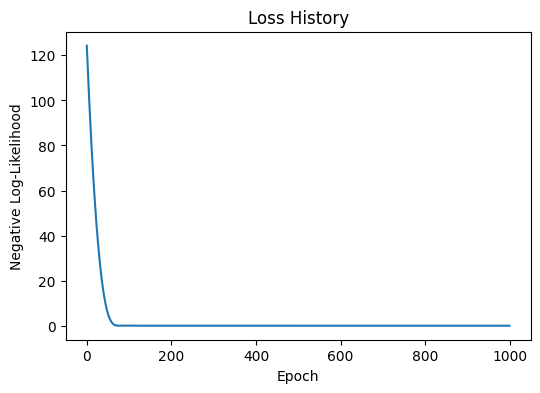

In [7]:
# Set up parameters for optimization.
# We optimize log parameters so that the exponentiated values remain positive.
# log_tau_e = torch.tensor(np.log(tau_e), dtype=torch.float64, requires_grad=True)
# log_tau_f = torch.tensor(np.log(tau_f), dtype=torch.float64, requires_grad=True)
# log_sigma = torch.tensor(np.log(sigma), dtype=torch.float64, requires_grad=True)

log_tau_e = torch.tensor(np.log(0.06), dtype=torch.float64, requires_grad=True)
log_tau_f = torch.tensor(np.log(0.05), dtype=torch.float64, requires_grad=False)
log_sigma = torch.tensor(np.log(2.0), dtype=torch.float64, requires_grad=True)


# print the intial parameters
print("Initial parameters:")
print(f"tau_e: {torch.exp(log_tau_e).item()}")
print(f"tau_f: {torch.exp(log_tau_f).item()}")
print(f"kappa: {torch.exp(log_tau_f).item() / torch.exp(log_tau_e).item()}")
print(f"sigma: {torch.exp(log_sigma).item()}")

print("Analytical mean and variance with intial parameters:")
model_init = formula.GaussianUpCrossingsDimless_minimal(r_func=process.r_OU_noise, u=u, tau=torch.exp(log_tau_e).item(), kappa=torch.exp(log_tau_f).item() / torch.exp(log_tau_e).item(), sigma=torch.exp(log_sigma).item())
mean_num_upcrossings_init = model_init.upcrossing_mean(T)
variance_num_upcrossings_init = model_init.upcrossing_variance(T)
print(f"Mean number of upcrossings : {mean_num_upcrossings_init}")
print(f"Variance of the number of upcrossings : {variance_num_upcrossings_init}")

print(f"epsilon_right = {1 - (T / torch.exp(log_tau_e).item()) / (1 + (T / torch.exp(log_tau_e).item()))}")


# Choose an optimizer
optimizer = torch.optim.Adam([log_tau_e, log_tau_f, log_sigma], lr=1e-2)

# For tracking the loss history
num_epochs = 1000
loss_history = []

# --------------------------------------------------------------------
# Optimization loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Convert log parameters to actual parameters ensuring positivity.
    tau_e_est = torch.exp(log_tau_e)
    tau_f_est = torch.exp(log_tau_f)
    sigma_est = torch.exp(log_sigma)
    kappa_est = tau_f_est / tau_e_est  # kappa is defined as tau_f/tau_e.
    
    # Create a model instance with the current estimates.
    model_est = formula.GaussianUpCrossingsDimless_minimal(
        r_func=process.r_OU_noise, u=u, tau=tau_e_est, kappa=kappa_est, sigma=sigma_est
    )
    
    # Compute the predicted mean and variance for the number of upcrossings over time T.
    mean_est = model_est.upcrossing_mean(T)
    var_est = model_est.upcrossing_variance(T)
    # var_est = model_est.upcrossing_variance_CLT(T)

    # print(f"Mean number of upcrossings: {mean_est}")
    # print(f"Variance of the number of upcrossings: {var_est}")
    
    # Define the negative log likelihood assuming a Gaussian likelihood for the counts.
    # For each trial, NLL = 0.5*log(2*pi*var) + 0.5*(observed - mean)^2 / var.
    # nll = 0.5 * torch.log(2 * torch.pi * var_est) + 0.5 * ((observed_counts - mean_est)**2) / var_est
    # nll = (observed_counts - mean_est)**2 ## minimize the mean
    # loss = nll.mean()  # Sum over all trials.

    
    # loss = (mean_est - true_mean) ** 2 ## minimize the mean
    # loss = (var_est - true_var) ** 2 ## minimize the variance
    loss = (mean_est - true_mean) ** 2 + (var_est - true_var) ** 2 ## minimize both mean and variance

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d}: Loss = {loss.item():.4f}, "
              f"tau_e = {tau_e_est.item():.6f}, tau_f = {tau_f_est.item():.6f}, kappa = {(tau_f_est.item() / tau_e_est.item()):.6f}, sigma = {sigma_est.item():.6f}")

    
    # Backpropagate the loss.
    loss.backward()

    # print the gradient for each parameter
    # print(f"Gradient tau_e: {log_tau_e.grad}")
    # print(f"Gradient sigma : {log_sigma.grad}")

    optimizer.step()
    
    loss_history.append(loss.item())
    

print("Optimization complete!")
print("Estimated parameters:")
print(f"tau_e: {torch.exp(log_tau_e).item()}")
print(f"tau_f: {torch.exp(log_tau_f).item()}")
print(f"sigma: {torch.exp(log_sigma).item()}")

# Optional: Plot loss history
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Loss History")
plt.show()

In [6]:
# print the simulation mean and variance with true paramters and learned paramteres
print("Simulation mean and variance with true parameters:")
print(f"Mean number of upcrossings: {torch.mean(observed_counts)}")
print(f"Variance of the number of upcrossings: {torch.var(observed_counts, correction=0)} \n")

# print the analytical mean and variance with true paramters and learned paramteres
print("Analytical mean and variance with true parameters:")
print(f"Mean number of upcrossings: {mean_num_upcrossings}")
print(f"Variance of the number of upcrossings: {variance_num_upcrossings} \n")


print("Analytical mean and variance with estimated parameters:")
model_est = formula.GaussianUpCrossingsDimless_minimal(r_func=process.r_OU_noise, u=u, tau=tau_e_est, kappa=kappa_est, sigma=sigma_est)
mean_num_upcrossings_est = model_est.upcrossing_mean(T)
variance_num_upcrossings_est = model_est.upcrossing_variance(T)
print(f"Mean number of upcrossings (estimated): {mean_num_upcrossings_est}")
print(f"Variance of the number of upcrossings (estimated): {variance_num_upcrossings_est}")

Simulation mean and variance with true parameters:
Mean number of upcrossings: 16.530000686645508
Variance of the number of upcrossings: 13.589099884033203 

Analytical mean and variance with true parameters:
Mean number of upcrossings: 16.719019568466106
Variance of the number of upcrossings: 13.353575069194134 

Analytical mean and variance with estimated parameters:
Mean number of upcrossings (estimated): 16.718990051849122
Variance of the number of upcrossings (estimated): 13.353523716932973
